In [1]:
# ============================================================
# Normalize "African Mining Equipment Failure.csv" to 3NF
# (3NF implies 2NF; you'll get a clean relational structure)
# Output tables:
#   1) equipment (PK: equipment_id)
#   2) failure_events (PK: event_id, FK: equipment_id)
#   3) event_impacts (PK/FK: event_id -> failure_events.event_id)
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path

# -----------------------------
# 0) Load
# -----------------------------
DATA_PATH = Path("African Mining Equipment Failure.csv")  # adjust if needed
df = pd.read_csv(DATA_PATH)

print("Loaded rows:", len(df))
print("Columns:", df.columns.tolist())

# -----------------------------
# 1) Standardize column names (optional but strongly recommended)
#    This block tries to map common variants to your expected names.
#    If your columns already match, it will effectively do nothing.
# -----------------------------
col_map_candidates = {
    # IDs
    "record_id": ["record_id", "Record ID", "recordId", "event_id", "Event ID"],
    "equipment_id": ["equipment_id", "Equipment ID", "equipmentId", "unit_id", "Unit ID"],

    # Equipment attributes
    "equipment_type": ["equipment_type", "Equipment Type", "asset_type", "Asset Type"],
    "manufacturer": ["manufacturer", "Manufacturer", "make", "Make"],
    "model_year": ["model_year", "Model Year", "year", "Year"],
    "mine_type": ["mine_type", "Mine Type"],
    "country": ["country", "Country"],

    # Event attributes
    "event_date": ["event_date", "Event Date", "date", "Date"],
    "event_type": ["event_type", "Event Type"],
    "failure_mode": ["failure_mode", "Failure Mode"],
    "component_failed": ["component_failed", "Component Failed", "failed_component"],
    "severity": ["severity", "Severity"],
    "maintenance_type": ["maintenance_type", "Maintenance Type"],
    "was_scheduled": ["was_scheduled", "Was Scheduled", "scheduled"],

    # Operational fields
    "operating_hours": ["operating_hours", "Operating Hours"],
    "days_since_last_service": ["days_since_last_service", "Days Since Last Service"],

    # Impacts
    "downtime_hours": ["downtime_hours", "Downtime Hours", "downtime"],
    "repair_cost_usd": ["repair_cost_usd", "Repair Cost USD", "repair_cost"],
    "production_loss_tonnes": ["production_loss_tonnes", "Production Loss Tonnes", "production_loss"],

    # Flags
    "oil_analysis_flag": ["oil_analysis_flag", "Oil Analysis Flag"],
    "vibration_flag": ["vibration_flag", "Vibration Flag"],
    "temperature_flag": ["temperature_flag", "Temperature Flag"],
}

# Build a rename map by finding the first matching candidate column in df
rename_map = {}
df_cols_lower = {c.lower(): c for c in df.columns}

for target, candidates in col_map_candidates.items():
    found = None
    for c in candidates:
        if c in df.columns:
            found = c
            break
        # try case-insensitive match
        if c.lower() in df_cols_lower:
            found = df_cols_lower[c.lower()]
            break
    if found is not None and found != target:
        rename_map[found] = target

df = df.rename(columns=rename_map)

# Sanity check: ensure we have the expected core columns
required = ["equipment_id", "record_id"]
missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise ValueError(
        f"Missing required columns after renaming: {missing_required}. "
        f"Current columns: {df.columns.tolist()}"
    )

# We'll treat record_id as event_id to match your SQL schema
df["event_id"] = df["record_id"].astype(str)

# -----------------------------
# 2) Basic cleaning / typing
# -----------------------------

# Normalize string keys (strip spaces)
df["equipment_id"] = df["equipment_id"].astype(str).str.strip()
df["event_id"] = df["event_id"].astype(str).str.strip()

# Replace empty strings with NaN for keys
df.loc[df["equipment_id"].eq("") | df["equipment_id"].str.lower().eq("nan"), "equipment_id"] = np.nan
df.loc[df["event_id"].eq("") | df["event_id"].str.lower().eq("nan"), "event_id"] = np.nan

# Parse dates if present
if "event_date" in df.columns:
    df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce").dt.date

# Convert numeric columns if present
num_cols = ["model_year", "operating_hours", "days_since_last_service",
            "downtime_hours", "repair_cost_usd", "production_loss_tonnes"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Convert flags to 0/1 if present
flag_cols = ["oil_analysis_flag", "vibration_flag", "temperature_flag"]
for c in flag_cols:
    if c in df.columns:
        # handles 1/0, True/False, "True"/"False", yes/no, etc.
        df[c] = (
            df[c]
            .replace({"True": 1, "False": 0, True: 1, False: 0, "YES": 1, "NO": 0, "Yes": 1, "No": 0})
        )
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0).astype(int)

# Convert was_scheduled to 0/1 if present
if "was_scheduled" in df.columns:
    df["was_scheduled"] = (
        df["was_scheduled"]
        .replace({"True": 1, "False": 0, True: 1, False: 0, "YES": 1, "NO": 0, "Yes": 1, "No": 0})
    )
    df["was_scheduled"] = pd.to_numeric(df["was_scheduled"], errors="coerce").fillna(0).astype(int)

# -----------------------------
# 3) Key integrity checks (before normalization)
# -----------------------------
print("\n--- Key integrity checks ---")
print("Null equipment_id:", df["equipment_id"].isna().sum())
print("Null event_id:", df["event_id"].isna().sum())

# Duplicate event_id check (this is THE most important check)
dup_event = df["event_id"].duplicated(keep=False)
print("Duplicate event_id rows:", int(dup_event.sum()))
if dup_event.any():
    print("Example duplicate event_ids:", df.loc[dup_event, "event_id"].head(10).tolist())

# If event_id duplicates exist, we must deduplicate deterministically.
# Strategy: keep the first row per event_id (you can change to last or a rule-based aggregation).
if dup_event.any():
    df = df.sort_values(by=["event_id"]).drop_duplicates(subset=["event_id"], keep="first")
    print("After deduplication, rows:", len(df))

# Drop rows missing keys required for relational integrity
df_clean = df.dropna(subset=["event_id", "equipment_id"]).copy()
print("After dropping missing keys, rows:", len(df_clean))

# -----------------------------
# 4) Build 3NF tables
# -----------------------------

# ---- 4.1 Equipment dimension (PK = equipment_id)
equipment_cols = [c for c in ["equipment_id", "equipment_type", "manufacturer", "model_year", "mine_type", "country"]
                  if c in df_clean.columns]

equipment = (
    df_clean[equipment_cols]
    .drop_duplicates(subset=["equipment_id"])
    .sort_values("equipment_id")
    .reset_index(drop=True)
)

# ---- 4.2 Failure events (PK = event_id, FK = equipment_id)
failure_cols = [c for c in ["event_id", "equipment_id", "event_date", "event_type", "failure_mode",
                            "component_failed", "severity", "maintenance_type", "was_scheduled",
                            "operating_hours", "days_since_last_service"]
                if c in df_clean.columns]

failure_events = (
    df_clean[failure_cols]
    .drop_duplicates(subset=["event_id"])
    .sort_values("event_id")
    .reset_index(drop=True)
)

# ---- 4.3 Event impacts (PK/FK = event_id)
impact_cols = [c for c in ["event_id", "downtime_hours", "repair_cost_usd", "production_loss_tonnes",
                           "oil_analysis_flag", "vibration_flag", "temperature_flag"]
               if c in df_clean.columns]

event_impacts = (
    df_clean[impact_cols]
    .drop_duplicates(subset=["event_id"])
    .sort_values("event_id")
    .reset_index(drop=True)
)

# -----------------------------
# 5) Relational integrity checks (post-normalization)
# -----------------------------
print("\n--- Post-normalization checks ---")

# A) failure_events -> equipment (should be 0 orphans)
orph_fail = failure_events.merge(equipment[["equipment_id"]], on="equipment_id", how="left", indicator=True)
orph_fail_count = (orph_fail["_merge"] == "left_only").sum()
print("Orphan equipment_id in failure_events:", int(orph_fail_count))

# B) event_impacts -> failure_events (should be 0 orphans)
orph_imp = event_impacts.merge(failure_events[["event_id"]], on="event_id", how="left", indicator=True)
orph_imp_count = (orph_imp["_merge"] == "left_only").sum()
print("Orphan event_id in event_impacts:", int(orph_imp_count))

# C) Uniqueness checks for PKs
print("equipment_id unique?", equipment["equipment_id"].is_unique)
print("event_id unique in failure_events?", failure_events["event_id"].is_unique)
print("event_id unique in event_impacts?", event_impacts["event_id"].is_unique)

# -----------------------------
# 6) Output + preview
# -----------------------------
print("\n--- Shapes ---")
print("equipment:", equipment.shape)
print("failure_events:", failure_events.shape)
print("event_impacts:", event_impacts.shape)

display(equipment.head(5))
display(failure_events.head(5))
display(event_impacts.head(5))

# Export
equipment.to_csv("equipment_3nf.csv", index=False)
failure_events.to_csv("failure_events_3nf.csv", index=False)
event_impacts.to_csv("event_impacts_3nf.csv", index=False)

print("\nSaved: equipment_3nf.csv, failure_events_3nf.csv, event_impacts_3nf.csv")


Loaded rows: 5000
Columns: ['record_id', 'equipment_id', 'equipment_type', 'manufacturer', 'model_year', 'mine_type', 'country', 'operating_hours', 'event_date', 'event_type', 'failure_mode', 'component_failed', 'severity', 'downtime_hours', 'repair_cost_usd', 'production_loss_tonnes', 'maintenance_type', 'was_scheduled', 'days_since_last_service', 'oil_analysis_flag', 'vibration_flag', 'temperature_flag']

--- Key integrity checks ---
Null equipment_id: 0
Null event_id: 0
Duplicate event_id rows: 0
After dropping missing keys, rows: 5000

--- Post-normalization checks ---
Orphan equipment_id in failure_events: 0
Orphan event_id in event_impacts: 0
equipment_id unique? True
event_id unique in failure_events? True
event_id unique in event_impacts? True

--- Shapes ---
equipment: (3825, 6)
failure_events: (5000, 11)
event_impacts: (5000, 7)


/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_24486/2788549777.py:125: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"True": 1, "False": 0, True: 1, False: 0, "YES": 1, "NO": 0, "Yes": 1, "No": 0})
/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_24486/2788549777.py:125: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace({"True": 1, "False": 0, True: 1, False: 0, "YES": 1, "NO": 0, "Yes": 1, "No": 0})
/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_24486/2788549777.py:125: FutureWarn

,equipment_id,equipment_type,manufacturer,model_year,mine_type,country
0,UNIT-1004,haul_truck,Komatsu,2022,open_pit,south_africa
1,UNIT-1005,drill_rig,Epiroc,2016,open_pit,tanzania
2,UNIT-1009,haul_truck,Belaz,2013,processing_plant,zimbabwe
3,UNIT-1011,drill_rig,Epiroc,2021,processing_plant,ghana
4,UNIT-1013,conveyor,ThyssenKrupp,2019,open_pit,south_africa


,event_id,equipment_id,event_date,event_type,failure_mode,component_failed,severity,maintenance_type,was_scheduled,operating_hours,days_since_last_service
0,EQP-0002425A,UNIT-5778,2021-04-08,breakdown,belt,general_component,minor,corrective,0,9433,46
1,EQP-0027EFEF,UNIT-3962,2021-06-05,condition_based,motor,general_component,routine,predictive,0,2290,67
2,EQP-0038A3B0,UNIT-2256,2020-09-14,scheduled_maintenance,preventive,adjustment,routine,preventive,1,18598,108
3,EQP-00527FD2,UNIT-6452,2021-11-30,scheduled_maintenance,preventive,filter_replace,routine,preventive,1,29847,39
4,EQP-005EC16F,UNIT-9349,2022-01-04,scheduled_maintenance,preventive,inspection,minor,preventive,1,63635,49


,event_id,downtime_hours,repair_cost_usd,production_loss_tonnes,oil_analysis_flag,vibration_flag,temperature_flag
0,EQP-0002425A,3.4,3118.37,1038.0,0,0,0
1,EQP-0027EFEF,5.4,3781.80,1518.0,0,1,0
2,EQP-0038A3B0,2.2,6959.43,205.0,0,0,0
3,EQP-00527FD2,5.7,4198.93,1017.0,0,0,0
4,EQP-005EC16F,13.2,35623.54,1749.0,0,0,0



Saved: equipment_3nf.csv, failure_events_3nf.csv, event_impacts_3nf.csv


In [2]:
# ============================================================
# Save normalized 3NF tables into ONE CSV (stacked + labeled)
# ============================================================

def tag_table(df, table_name):
    df_out = df.copy()
    df_out.insert(0, "table_name", table_name)
    return df_out

equipment_tagged = tag_table(equipment, "equipment")
failure_events_tagged = tag_table(failure_events, "failure_events")
event_impacts_tagged = tag_table(event_impacts, "event_impacts")

# Align columns (union of all columns)
all_cols = sorted(
    set(equipment_tagged.columns)
    | set(failure_events_tagged.columns)
    | set(event_impacts_tagged.columns)
)

equipment_tagged = equipment_tagged.reindex(columns=all_cols)
failure_events_tagged = failure_events_tagged.reindex(columns=all_cols)
event_impacts_tagged = event_impacts_tagged.reindex(columns=all_cols)

# Stack into one CSV
normalized_one_csv = pd.concat(
    [equipment_tagged, failure_events_tagged, event_impacts_tagged],
    ignore_index=True
)

normalized_one_csv.to_csv("mining_reliability_normalized_3nf.csv", index=False)

print("Saved: mining_reliability_normalized_3nf.csv")


Saved: mining_reliability_normalized_3nf.csv


/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_24486/3388074786.py:154: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby("severity")
/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_24486/3388074786.py:174: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby("severity")


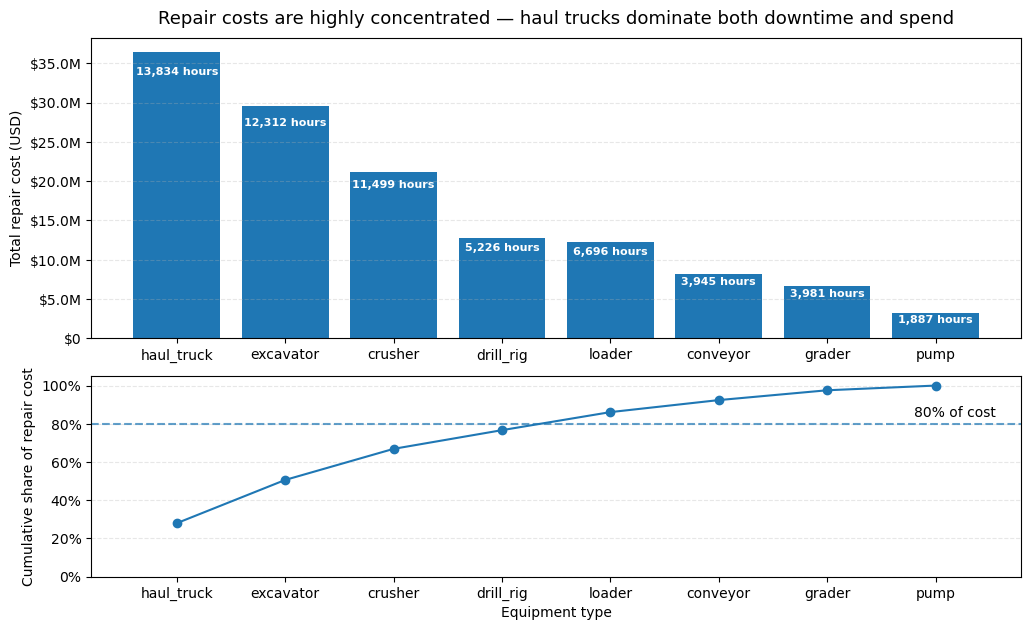

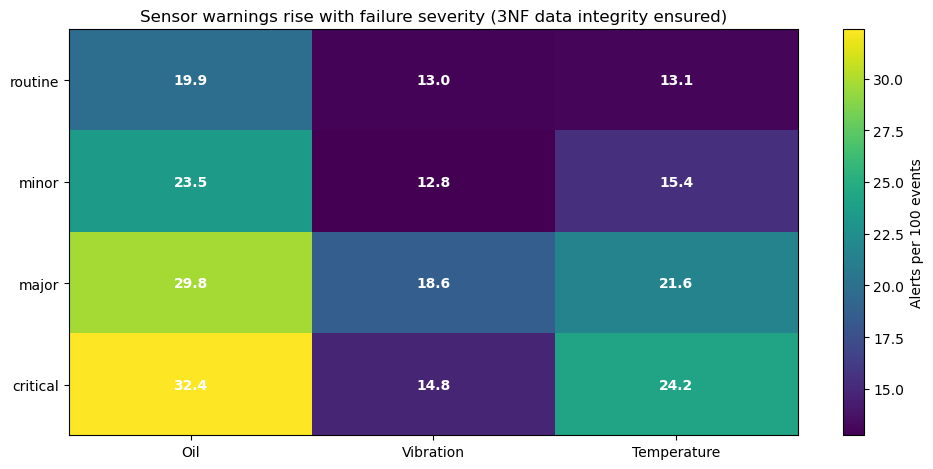

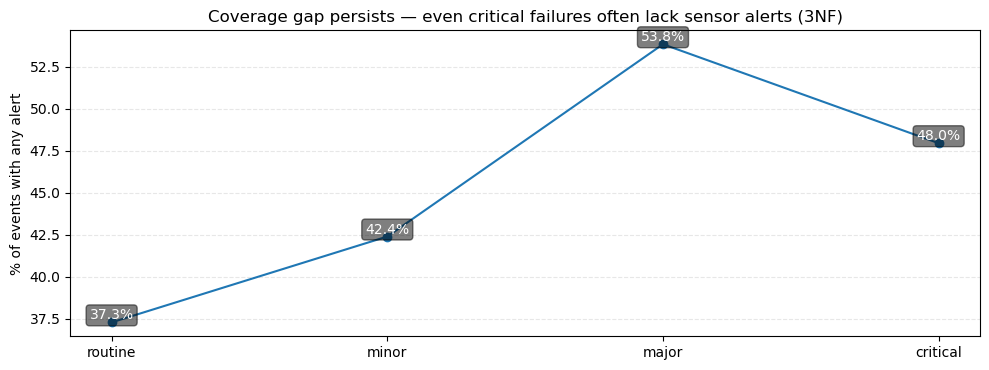

/var/folders/qd/cg9ht7c952714rst8b_tj8yh0000gn/T/ipykernel_24486/3388074786.py:224: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df3.groupby("maintenance_type")


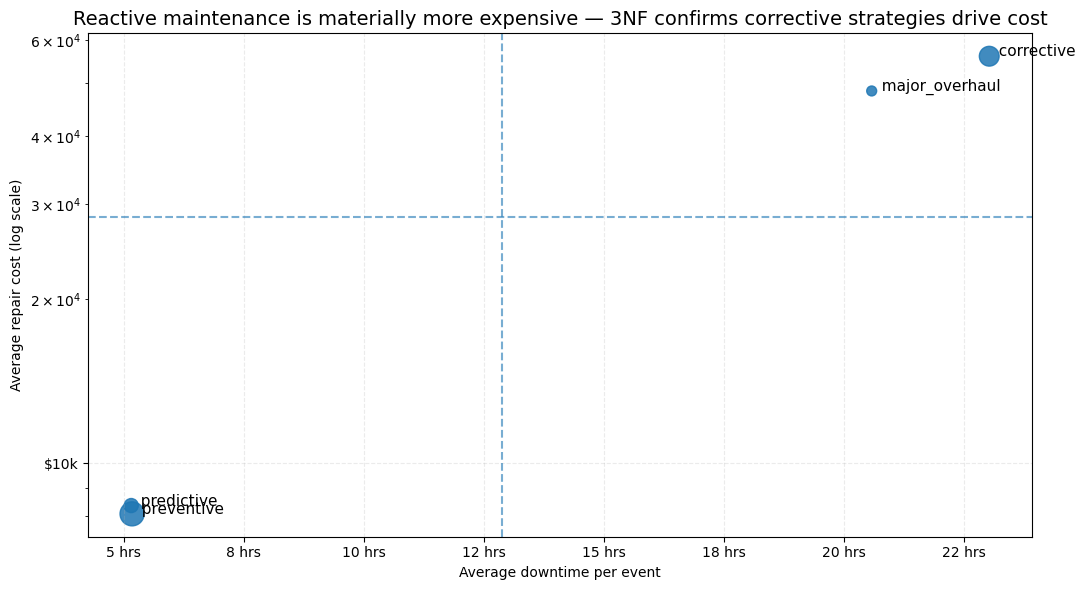

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ------------------------------------------------------------
# 0) Load 3NF tables
# ------------------------------------------------------------
equipment = pd.read_csv("equipment_3nf.csv")
failure_events = pd.read_csv("failure_events_3nf.csv")
event_impacts = pd.read_csv("event_impacts_3nf.csv")

# Defensive cleanup
for df in [equipment, failure_events, event_impacts]:
    df.columns = [c.strip() for c in df.columns]

# ------------------------------------------------------------
# 1) Build analysis dataframe via 3NF joins
# ------------------------------------------------------------
df = (
    failure_events
    .merge(event_impacts, on="event_id", how="inner")
    .merge(equipment, on="equipment_id", how="inner")
)

# Coerce numerics
num_cols = [
    "downtime_hours", "repair_cost_usd", "production_loss_tonnes",
    "operating_hours", "days_since_last_service"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Sensor flags → 0/1
flag_cols = ["oil_analysis_flag", "vibration_flag", "temperature_flag"]
for c in flag_cols:
    df[c] = df[c].astype(int)

# ------------------------------------------------------------
# Helper formatters
# ------------------------------------------------------------
def fmt_usd(x, _):
    if abs(x) >= 1e6:
        return f"${x/1e6:.1f}M"
    if abs(x) >= 1e3:
        return f"${x/1e3:.0f}k"
    return f"${x:.0f}"

def fmt_hours(x, _):
    if abs(x) >= 1e3:
        return f"{x/1e3:.1f}k hrs"
    return f"{x:.0f} hrs"

# ============================================================
# 1) Cost & downtime by equipment type
# ============================================================

g1 = (
    df.groupby("equipment_type")
      .agg(
          event_count=("event_id", "count"),
          total_downtime_hours=("downtime_hours", "sum"),
          total_repair_cost_usd=("repair_cost_usd", "sum"),
          total_production_loss_tonnes=("production_loss_tonnes", "sum")
      )
      .sort_values("total_repair_cost_usd", ascending=False)
      .reset_index()
)

g1["cum_cost_share"] = g1["total_repair_cost_usd"].cumsum() / g1["total_repair_cost_usd"].sum()
TOP_N = 10
g1p = g1.head(TOP_N)

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 2], hspace=0.15)

# Bars
# Panel A: repair cost bars
ax1 = fig.add_subplot(gs[0])
ax1.bar(g1p["equipment_type"], g1p["total_repair_cost_usd"])
ax1.set_ylabel("Total repair cost (USD)")
ax1.yaxis.set_major_formatter(FuncFormatter(fmt_usd))
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# 👉 Insight-driven title for the bar chart
ax1.set_title(
    "Repair costs are highly concentrated — haul trucks dominate both downtime and spend",
    fontsize=13,
    pad=10
)

# --- Annotate downtime INSIDE bars (prevents clipping) ---
bars = ax1.patches

for bar, hrs in zip(bars, g1p["total_downtime_hours"].values):
    if pd.isna(hrs):
        continue

    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_height()

    ax1.text(
        x, y * 0.95,                    # slightly below the top of the bar
        f"{hrs:,.0f} hours",
        ha="center", va="top",
        fontsize=8,
        color="white",                  # high contrast
        fontweight="bold"
    )


# Pareto line
# Panel B: cumulative cost share line (separate axis, separate panel)
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(g1p["equipment_type"], g1p["cum_cost_share"], marker="o")

ax2.set_ylabel("Cumulative share of repair cost")
ax2.set_ylim(0, 1.05)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.0f}%"))
ax2.grid(axis="y", linestyle="--", alpha=0.3)

# Ensure x-axis labels are visible on the bottom chart
ax2.set_xlabel("Equipment type")
ax2.tick_params(axis="x", labelbottom=True)
plt.setp(ax2.get_xticklabels(), rotation=0, ha="center")

# Reference line at 80% with non-overlapping label
y_ref = 0.80
ax2.axhline(y_ref, linestyle="--", alpha=0.7)

# Place the label slightly ABOVE the dashed line and slightly LEFT of the last point
x_last = len(g1p) - 1
y_last = float(g1p["cum_cost_share"].iloc[-1])

# If the last point is close to 80%, push the label a bit more to avoid overlap
y_offset = 0.03 if abs(y_last - y_ref) < 0.05 else 0.02
ax2.text(
    x_last - 0.2, y_ref + y_offset, "80% of cost",
    ha="left", va="bottom", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.85, edgecolor="none")
)


# ============================================================
# 2) Sensor alerts vs severity
# ============================================================

severity_order = ["routine", "minor", "major", "critical"]
df2 = df[df["severity"].isin(severity_order)].copy()
df2["severity"] = pd.Categorical(df2["severity"], severity_order, ordered=True)

g2 = (
    df2.groupby("severity")
       .agg(
           event_count=("event_id", "count"),
           oil=("oil_analysis_flag", "sum"),
           vibration=("vibration_flag", "sum"),
           temperature=("temperature_flag", "sum")
       )
       .reset_index()
)

for c in ["oil", "vibration", "temperature"]:
    g2[c] = 100 * g2[c] / g2["event_count"]

df2["any_alert"] = (
    (df2["oil_analysis_flag"] == 1) |
    (df2["vibration_flag"] == 1) |
    (df2["temperature_flag"] == 1)
).astype(int)

any_alert = (
    df2.groupby("severity")
       .agg(pct_any_alert=("any_alert", "mean"))
       .reset_index()
)
any_alert["pct_any_alert"] *= 100

# Heatmap
mat = g2.set_index("severity")[["oil", "vibration", "temperature"]].values
fig, ax = plt.subplots(figsize=(10, 4.8))
im = ax.imshow(mat, aspect="auto")

ax.set_xticks(range(3))
ax.set_xticklabels(["Oil", "Vibration", "Temperature"])
ax.set_yticks(range(len(severity_order)))
ax.set_yticklabels(severity_order)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        ax.text(j, i, f"{mat[i, j]:.1f}", ha="center", va="center",
                color="white", fontweight="bold")

plt.colorbar(im, ax=ax, label="Alerts per 100 events")
ax.set_title("Sensor warnings rise with failure severity (3NF data integrity ensured)")
plt.tight_layout()
plt.show()

# Any-alert line
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(any_alert["severity"], any_alert["pct_any_alert"], marker="o")
ax.set_ylabel("% of events with any alert")
ax.grid(axis="y", linestyle="--", alpha=0.3)

for i, v in enumerate(any_alert["pct_any_alert"]):
    ax.text(i, v, f"{v:.1f}%", ha="center", va="bottom",
            color="white",
            bbox=dict(facecolor="black", alpha=0.5, boxstyle="round,pad=0.25"))

ax.set_title("Coverage gap persists — even critical failures often lack sensor alerts (3NF)")
plt.tight_layout()
plt.show()

# ============================================================
# 3) Maintenance strategy cost vs downtime
# ============================================================

maint_order = ["preventive", "predictive", "major_overhaul", "corrective"]
df3 = df[df["maintenance_type"].isin(maint_order)].copy()
df3["maintenance_type"] = pd.Categorical(df3["maintenance_type"], maint_order, ordered=True)

g3 = (
    df3.groupby("maintenance_type")
       .agg(
           event_count=("event_id", "count"),
           avg_downtime_hours=("downtime_hours", "mean"),
           avg_repair_cost_usd=("repair_cost_usd", "mean"),
           avg_production_loss_tonnes=("production_loss_tonnes", "mean")
       )
       .reset_index()
)

sizes = 300 * g3["event_count"] / g3["event_count"].max()
x_med = g3["avg_downtime_hours"].median()
y_med = g3["avg_repair_cost_usd"].median()

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(g3["avg_downtime_hours"], g3["avg_repair_cost_usd"], s=sizes, alpha=0.85)
ax.set_yscale("log")
ax.yaxis.set_major_formatter(FuncFormatter(fmt_usd))
ax.xaxis.set_major_formatter(FuncFormatter(fmt_hours))

ax.axvline(x_med, linestyle="--", alpha=0.6)
ax.axhline(y_med, linestyle="--", alpha=0.6)

for _, r in g3.iterrows():
    ax.text(r["avg_downtime_hours"], r["avg_repair_cost_usd"],
            f"  {r['maintenance_type']}", fontsize=11)

ax.set_title(
    "Reactive maintenance is materially more expensive — 3NF confirms corrective strategies drive cost",
    fontsize=14
)
ax.set_xlabel("Average downtime per event")
ax.set_ylabel("Average repair cost (log scale)")
ax.grid(axis="both", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()
